지난번에 한 EDA 말고 컬럼 뽑기/그룹핑/정렬/시각화 위주로 다시 정리

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("ai4i2020.csv")
df.columns = [c.strip() for c in df.columns]
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### 컬럼 뽑아서 기초통계

In [2]:
# 온도, 토크, 공구마모만 따로 떼서 통계 확인
cols = ["Air temperature [K]", "Process temperature [K]", "Torque [Nm]", "Tool wear [min]"]
df[cols].describe()


,Air temperature [K],Process temperature [K],Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,39.986910,107.951000
std,2.000259,1.483734,9.968934,63.654147
min,295.300000,305.700000,3.800000,0.000000
25%,298.300000,308.800000,33.200000,53.000000
50%,300.100000,310.100000,40.100000,108.000000
75%,301.500000,311.100000,46.800000,162.000000
max,304.500000,313.800000,76.600000,253.000000


In [3]:
# Torque 하나만 콕 집어서 평균/중앙값 등 따로 뽑아보기
torque = df["Torque [Nm]"]
print("평균:", torque.mean())
print("중앙값:", torque.median())
print("표준편차:", torque.std())
print("최댓값:", torque.max())
print("최솟값:", torque.min())


평균: 39.986909999999995
중앙값: 40.1
표준편차: 9.968933725121337
최댓값: 76.6
최솟값: 3.8


### 전체 목록 확인

In [4]:
# 컬럼 잘리지 않게 옵션 풀고 전체 데이터 한번 쭉 보기
pd.set_option("display.max_columns", None)
df


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [6]:
print(df["Type"].unique())
print("제품 종류 개수:", df["Product ID"].nunique())


<StringArray>
[' M   ', ' L   ', ' H   ']
Length: 3, dtype: str
제품 종류 개수: 10000


### 그룹 지어서 컬럼 뽑기

In [7]:
# Type별로 묶어서 필요한 컬럼만
df.groupby("Type")[["Torque [Nm]", "Tool wear [min]", "Rotational speed [rpm]"]].mean()


,Torque [Nm],Tool wear [min],Rotational speed [rpm]
Type,,,
H,39.838285,107.419741,1538.147557
L,39.996600,108.378833,1539.469167
M,40.017251,107.272272,1537.598932


In [8]:
# 고장여부 기준으로도 한번
df.groupby("Machine failure")[["Air temperature [K]", "Process temperature [K]", "Torque [Nm]"]].mean()


,Air temperature [K],Process temperature [K],Torque [Nm]
Machine failure,,,
0,299.973999,309.995570,39.629655
1,300.886431,310.290265,50.168142


### 정렬 (내림차순 / 오름차순)

In [9]:
# 토크 큰 순서대로 (내림차순)
df.sort_values("Torque [Nm]", ascending=False)[["Product ID", "Type", "Torque [Nm]", "Machine failure"]].head(10)


,Product ID,Type,Torque [Nm],Machine failure
7763,L54943,L,76.6,1
880,M15740,M,76.2,1
9084,L56264,L,75.4,1
1324,M16184,M,74.5,1
6525,L53705,L,73.6,1
3000,H32414,H,72.8,1
8582,M23442,M,72.0,1
7569,L54749,L,71.8,1
603,L47783,L,71.6,1
5615,M20475,M,71.3,1


In [10]:
# 공구 마모 적은 순서대로 (오름차순)
df.sort_values("Tool wear [min]", ascending=True)[["Product ID", "Type", "Tool wear [min]", "Machine failure"]].head(10)


,Product ID,Type,Tool wear [min],Machine failure
6341,M21201,M,0,0
8358,L55538,L,0,0
593,L47773,L,0,0
6257,L53437,L,0,0
7427,L54607,L,0,0
4035,L51215,L,0,0
1839,L49019,L,0,0
1510,M16370,M,0,0
1174,M16034,M,0,0
7594,L54774,L,0,0


### 시각화

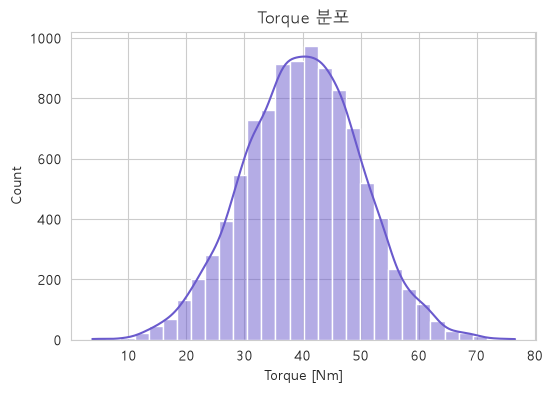

In [11]:
plt.figure(figsize=(6, 4))
sns.histplot(df["Torque [Nm]"], bins=30, kde=True, color="slateblue")
plt.title("Torque 분포")
plt.show()


40 근처에 제일 몰려있고 좌우로 완만하게 퍼지는 모양. 60 넘는 값은 거의 안 보임

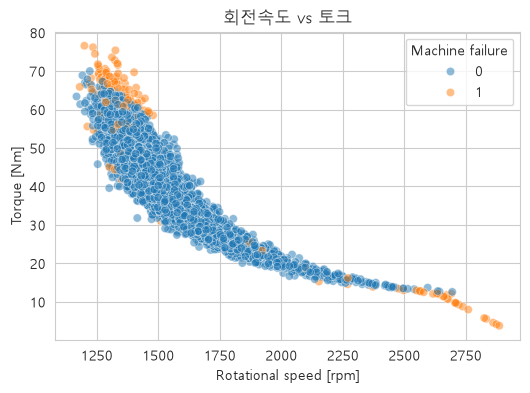

In [12]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="Rotational speed [rpm]", y="Torque [Nm]", hue="Machine failure", alpha=0.5)
plt.title("회전속도 vs 토크")
plt.show()


회전속도 올라가면 토크는 내려가는 반비례 모양이 뚜렷하고, 고장난 점들(주황)은 토크 높거나 회전속도 낮은 쪽에 몰려있음

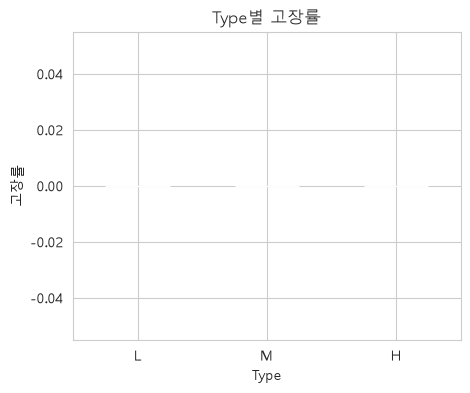

In [13]:
fail_rate = df.groupby("Type")["Machine failure"].mean().reindex(["L", "M", "H"])
plt.figure(figsize=(5, 4))
fail_rate.plot(kind="bar", color=["#4c72b0", "#55a868", "#c44e52"])
plt.title("Type별 고장률")
plt.ylabel("고장률")
plt.xticks(rotation=0)
plt.show()


L 등급이 고장률 제일 높고 H로 갈수록 낮아짐. 저가형일수록 좀 더 잘 고장나는 듯

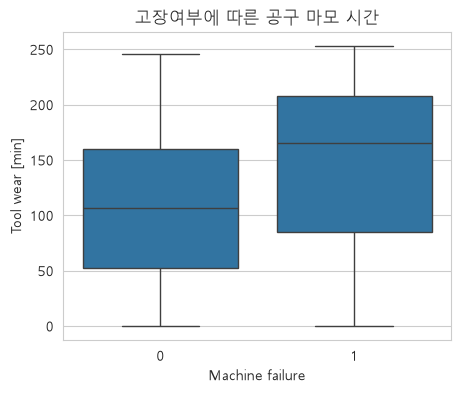

In [14]:
plt.figure(figsize=(5, 4))
sns.boxplot(data=df, x="Machine failure", y="Tool wear [min]")
plt.title("고장여부에 따른 공구 마모 시간")
plt.show()


고장난 쪽(1)이 공구 마모 시간 중앙값이 더 높음. 마모가 쌓일수록 고장 날 확률도 올라가는 것 같음